# Práctica 2: Sección 3.6
## Descriptores clásicos: Local Binary Patterns (LBP) y Histogram of Oriented Gradients (HOG)

**Entrada:** `muestra_procesada`, lista de tuplas `(ruta, clase, bgr, mascara)`.

**Salida:**
- Mapas de características visuales (LBP y HOG) en `figs/`.
- Matriz de datos procesada (LBP + HOG combinados) en `features/`

---
### Contenido
1. Configuración y reconstrucción del pipeline base
2. Preparación de la imagen para los descriptores
3. LBP:textura local
4. HOG:gradientes y estructura
5. Vector combinado (LBP + HOG)
6. Armado de la matriz de datos para clasificación
7. Conclusiones

## 1. Configuración y pipeline base

> Las funciones de esta sección son una **copia fiel** de la celda 3 de
> `practica_2_playground.ipynb`. Si el pipeline cambia, actualizar `CONFIG_PIPELINE`.
>
> (Mejora pendiente para el grupo: mover estas funciones a un `pipeline.py`
> que ambos notebooks importen, para no duplicar código.)

In [1]:
import os, random
import numpy as np
import cv2
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

# ---- Dataset ----
LOCAL_DATASET = False   # True si ya lo tienes descargado localmente

if LOCAL_DATASET:
    path = "../../../../../Downloads/archive"   # ajustar a tu ruta
else:
    import kagglehub
    path = kagglehub.dataset_download("emmarex/plantdisease")

DATA_DIR = os.path.join(path, "PlantVillage")
print("DATA_DIR:", DATA_DIR)

# ---- Carpetas de salida ----
FIGS = "figs"
FEATS = "features"
os.makedirs(FIGS, exist_ok=True)
os.makedirs(FEATS, exist_ok=True)

def guardar(nombre):
    """Guarda la figura actual en figs/ con buena resolución."""
    ruta = os.path.join(FIGS, nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print("guardado:", ruta)

/home/diegorandolp/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA_DIR: /home/diegorandolp/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage


In [2]:
# ============================================================
# COPIA del pipeline base (practica_2_playground.ipynb, celda 3)
# ============================================================

def to_grayscale(bgr):
    """Escala de grises por luminosidad (ITU-R BT.601)."""
    b, g, r = bgr[:, :, 0], bgr[:, :, 1], bgr[:, :, 2]
    return (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)

def aplicar_filtro(gray, filtro, ksize):
    if filtro == 'gaussian':
        return cv2.GaussianBlur(gray, (ksize, ksize), 0)
    elif filtro == 'median':
        return cv2.medianBlur(gray, ksize)
    raise ValueError("filtro debe ser 'gaussian' o 'median'")

def cdf_histograma(gray):
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
    cdf = np.cumsum(hist)
    return (cdf - cdf.min()) / (cdf.max() - cdf.min()) * 255

def ecualizar_histograma(gray):
    lut = cdf_histograma(gray).astype(np.uint8)
    return cv2.LUT(gray, lut)

def orient_leaf_as_foreground(mask):
    """Deja la hoja en blanco (asume que el fondo domina el borde de la imagen)."""
    border = np.concatenate([mask[0, :], mask[-1, :], mask[:, 0], mask[:, -1]])
    return cv2.bitwise_not(mask) if border.mean() > 100 else mask

def segmentar(gray, metodo, global_t=127):
    if metodo == 'global':
        _, m = cv2.threshold(gray, global_t, 255, cv2.THRESH_BINARY)
        return orient_leaf_as_foreground(m)
    elif metodo == 'otsu':
        _, m = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        return orient_leaf_as_foreground(m)
    raise ValueError("método desconocido: " + str(metodo))

def aplicar_morfologia(mask, operacion, ksize):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    if operacion == 'erosion':
        return cv2.erode(mask, kernel, iterations=1)
    elif operacion == 'dilatacion':
        return cv2.dilate(mask, kernel, iterations=1)
    elif operacion == 'apertura':
        return cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    elif operacion == 'cierre':
        return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    raise ValueError("operación desconocida: " + str(operacion))

def construir_pipeline(filtro='gaussian', ksize_filtro=5, contraste=False,
                       metodo_seg='otsu', global_t=127, operaciones_morf=()):
    pasos = [('Gris', to_grayscale)]
    if contraste:
        pasos.append(('Contraste (CDF)', ecualizar_histograma))
    pasos.append(('Filtro', lambda img: aplicar_filtro(img, filtro, ksize_filtro)))
    pasos.append(('Segmentacion', lambda img: segmentar(img, metodo_seg, global_t)))
    for op, ksize in operaciones_morf:
        pasos.append((op.capitalize() + " (k=" + str(ksize) + ")",
                      lambda img, op=op, ksize=ksize: aplicar_morfologia(img, op, ksize)))
    return pasos

def ejecutar_pipeline(bgr, pasos):
    actual = bgr
    for nombre, fn in pasos:
        actual = fn(actual)
    return actual

print("Funciones del pipeline listas.")

Funciones del pipeline listas.


In [3]:
# --- Configuración del pipeline final (P2, acordado por el grupo) ---
CONFIG_PIPELINE = dict(
    filtro='gaussian',
    ksize_filtro=5,
    contraste=True,
    metodo_seg='otsu',
    operaciones_morf=[('dilatacion', 11), ('erosion', 3)],
)

PIPELINE_FINAL = construir_pipeline(**CONFIG_PIPELINE)

def procesar_hasta_operaciones_morfologicas(ruta):
    """Corre el pipeline final sobre una imagen.
    Devuelve (bgr_original, mascara_binaria)."""
    bgr = cv2.imread(ruta)
    mascara = ejecutar_pipeline(bgr, PIPELINE_FINAL)
    return bgr, mascara

print("Pipeline:", " -> ".join(n for n, _ in PIPELINE_FINAL))

Pipeline: Gris -> Contraste (CDF) -> Filtro -> Segmentacion -> Dilatacion (k=11) -> Erosion (k=3)


### Selección de clases e imágenes de muestra

No necesitamos las 15 clases. Para las figuras del informe bastan **una hoja sana y
tres enfermas** con patrones visualmente distintos:

| Clase | Por qué |
|---|---|
| `Tomato_healthy` | Control: sin lesiones, superficie uniforme |
| `Tomato_Early_blight` | Lesiones grandes con anillos concéntricos |
| `Tomato_Septoria_leaf_spot` | Muchas manchas pequeñas y bien delimitadas |
| `Tomato__Tomato_YellowLeaf__Curl_Virus` | Deformación del contorno, sin manchas focales |

Para las **figuras** (mapas LBP/HOG) alcanza con una imagen por clase. Para la **matriz de
datos** de cara a la clasificación (3.7) se usan `N_POR_CLASE_DATOS` imágenes por clase.

In [4]:
def get_class_dirs(data_dir=DATA_DIR):
    return sorted(d for d in os.listdir(data_dir)
                  if os.path.isdir(os.path.join(data_dir, d))
                  and d.lower() != "plantvillage")

DISPONIBLES = get_class_dirs()

PATRONES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Septoria",
    "YellowLeaf",
]

def resolver_clases(patrones, disponibles=DISPONIBLES):
    elegidas = []
    for p in patrones:
        match = [c for c in disponibles if p.lower() in c.lower()]
        if match:
            elegidas.append(match[0])
        else:
            print("[!] no se encontró la clase:", p)
    return elegidas

CLASES_FOCO = resolver_clases(PATRONES)
print("Clases seleccionadas:")
for c in CLASES_FOCO:
    print("  -", c)

def es_sana(clase):
    return "healthy" in clase.lower()

def etiqueta_corta(clase):
    """Nombre legible para los títulos de las figuras."""
    return (clase.replace("Tomato_", "").replace("Tomato__", "")
                 .replace("_", " ").replace("  ", " ").strip())

def imagenes_de_clase(clase, data_dir=DATA_DIR, n=1, seed=42):
    random.seed(seed)
    cdir = os.path.join(data_dir, clase)
    exts = ('.png', '.jpg', '.jpeg', '.bmp')
    imgs = sorted(f for f in os.listdir(cdir) if f.lower().endswith(exts))
    return [os.path.join(cdir, f) for f in random.sample(imgs, min(n, len(imgs)))]

Clases seleccionadas:
  - Tomato_healthy
  - Tomato_Early_blight
  - Tomato_Septoria_leaf_spot
  - Tomato__Tomato_YellowLeaf__Curl_Virus


In [ ]:
# una imagen por clase
muestra_procesada = []
for clase in CLASES_FOCO:
    for ruta in imagenes_de_clase(clase, n=1):
        bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
        muestra_procesada.append((ruta, clase, bgr, mascara))

print("Imágenes de muestra:", len(muestra_procesada))
for ruta, clase, bgr, mascara in muestra_procesada:
    print("  ", etiqueta_corta(clase), "->", bgr.shape)

Imágenes de muestra: 4
   healthy -> (256, 256, 3)
   Early blight -> (256, 256, 3)
   Septoria leaf spot -> (256, 256, 3)
   YellowLeaf Curl Virus -> (256, 256, 3)


## 2. Preparación de la imagen para los descriptores

LBP y HOG se calculan sobre una sola banda de intensidad, no sobre color. Similar a 3.4/3.5, los descriptores se calculan **con el fondo descartado** (máscara aplicada sobre el gris) para que la textura/gradiente del fondo no contamine el vector de características de la hoja.

Además, HOG produce un vector cuya longitud depende del tamaño de la imagen de entrada. Como la matriz de datos final necesita una columna por característica igual para todas las filas, todas las imágenes se llevan a un tamaño fijo `TAM_DESCRIPTOR` antes de extraer los descriptores.

In [ ]:
TAM_DESCRIPTOR = (128, 128)  # tamaño fijo,vectores HOG de igual longitud para todas las imágenes

def preparar_para_descriptores(bgr, mascara, tam=TAM_DESCRIPTOR):
    """Gris + fondo descartado (mismo criterio que 3.4/3.5) + tamaño fijo."""
    gray = to_grayscale(bgr)
    gray = cv2.bitwise_and(gray, gray, mask=mascara)
    return cv2.resize(gray, tam, interpolation=cv2.INTER_AREA)

# Prueba
ruta, clase, bgr, mascara = muestra_procesada[0]
gray_prep = preparar_para_descriptores(bgr, mascara)
print(etiqueta_corta(clase), "->", gray_prep.shape, gray_prep.dtype)

healthy -> (128, 128) uint8


## 3. Sección 3.6: LBP 

**Local Binary Patterns.** Para cada píxel se compara su intensidad con la de sus `P` vecinos sobre un círculo de radio `R`: cada vecino aporta un bit (1 si es mayor o igual al centro, 0 sino) y esos bits forman un código de textura local. Se usa la variante **uniforme** (`method='uniform'`), que agrupa todos los patrones con más de 2 transiciones 0-1 en un único bin "no uniforme": son los más frecuentes en texturas reales y reduce el histograma de `2^P` a `P + 2` bins.

Con `P=8, R=1` (8 vecinos a distancia 1 px) el histograma queda en 10 bins. El **mapa LBP** es la imagen completa con el código de cada píxel; el **vector de características** es el histograma normalizado de esos códigos.

In [7]:
from skimage.feature import local_binary_pattern

LBP_RADIO = 1
LBP_PUNTOS = 8 * LBP_RADIO
LBP_METODO = 'uniform'
LBP_N_BINS = LBP_PUNTOS + 2   # patrones uniformes (0..P) + 1 bin para el resto

def lbp_mapa(gray):
    """Imagen donde cada píxel es su código LBP (textura local)."""
    return local_binary_pattern(gray, LBP_PUNTOS, LBP_RADIO, method=LBP_METODO)

def lbp_histograma(lbp_img):
    """Histograma normalizado del mapa LBP: el vector de características de textura."""
    hist, _ = np.histogram(lbp_img.ravel(), bins=LBP_N_BINS, range=(0, LBP_N_BINS))
    hist = hist.astype(np.float64)
    return hist / (hist.sum() + 1e-7)

# Prueba
h = lbp_histograma(lbp_mapa(gray_prep))
print("Histograma LBP:", h.shape, "| suma =", round(h.sum(), 3))

Histograma LBP: (10,) | suma = 1.0


guardado: figs/05_lbp_mapas.png


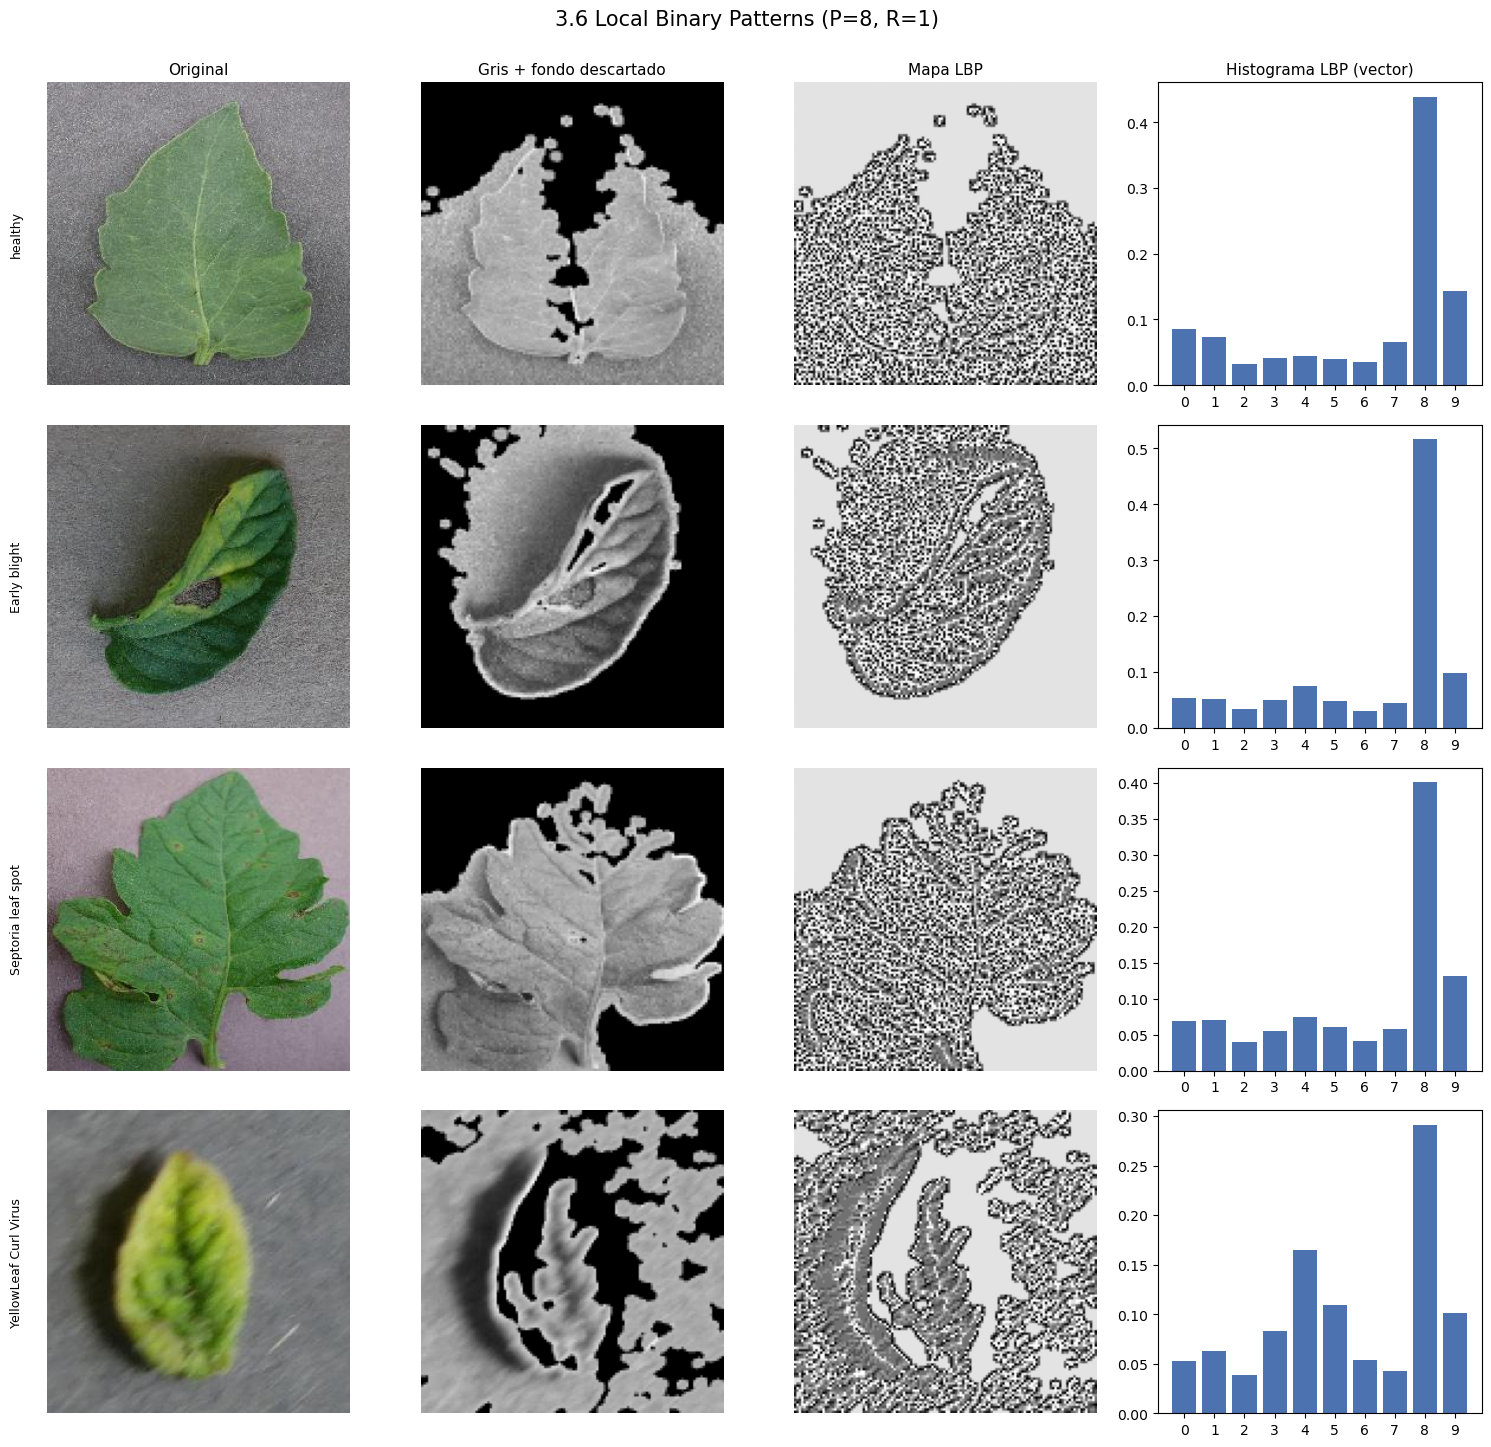

In [14]:
# --- Figura: mapas de LBP por clase ---
fig, axes = plt.subplots(len(muestra_procesada), 4,
                         figsize=(15, 3.6 * len(muestra_procesada)))
if len(muestra_procesada) == 1:
    axes = axes[np.newaxis, :]

for i, (ruta, clase, bgr, mascara) in enumerate(muestra_procesada):
    gray = preparar_para_descriptores(bgr, mascara)
    mapa = lbp_mapa(gray)
    hist = lbp_histograma(mapa)

    axes[i, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original" if i == 0 else "", fontsize=11)
    axes[i, 0].axis('off')
    axes[i, 0].text(-0.1, 0.5, etiqueta_corta(clase), transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title("Gris + fondo descartado" if i == 0 else "", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mapa, cmap='gray')
    axes[i, 2].set_title("Mapa LBP" if i == 0 else "", fontsize=11)
    axes[i, 2].axis('off')

    axes[i, 3].bar(range(LBP_N_BINS), hist, color="#4C72B0")
    axes[i, 3].set_title("Histograma LBP (vector)" if i == 0 else "", fontsize=11)
    axes[i, 3].set_xticks(range(LBP_N_BINS))

plt.suptitle("3.6 Local Binary Patterns (P=" + str(LBP_PUNTOS) + ", R=" + str(LBP_RADIO) + ")",
             fontsize=15, y=1.002)
plt.tight_layout()
guardar("05_lbp_mapas.png")
plt.show()

## 4. Sección 3.6: HOG

**Histogram of Oriented Gradients.** Divide la imagen en celdas, calcula el gradiente en cada píxel y arma un histograma de orientaciones por celda. Los histogramas se normalizan en bloques de celdas superpuestos para ser menos sensibles a cambios de iluminación. El resultado captura la forma y estructura de bordes/lesiones, a diferencia de LBP, que describe textura fina.

Parámetros clásicos (Dalal & Triggs): 9 orientaciones, celdas de 16x16 píxeles, bloques de 2x2
celdas.

In [9]:
from skimage.feature import hog

HOG_PARAMS = dict(orientations=9, pixels_per_cell=(16, 16),
                  cells_per_block=(2, 2), block_norm='L2-Hys')

def hog_vector_y_mapa(gray):
    """Vector HOG (características) + imagen de visualización de los gradientes."""
    vector, mapa = hog(gray, visualize=True, **HOG_PARAMS)
    return vector, mapa

# Prueba
v, m = hog_vector_y_mapa(gray_prep)
print("Vector HOG:", v.shape, "| mapa de visualización:", m.shape)

Vector HOG: (1764,) | mapa de visualización: (128, 128)


guardado: figs/06_hog_mapas.png


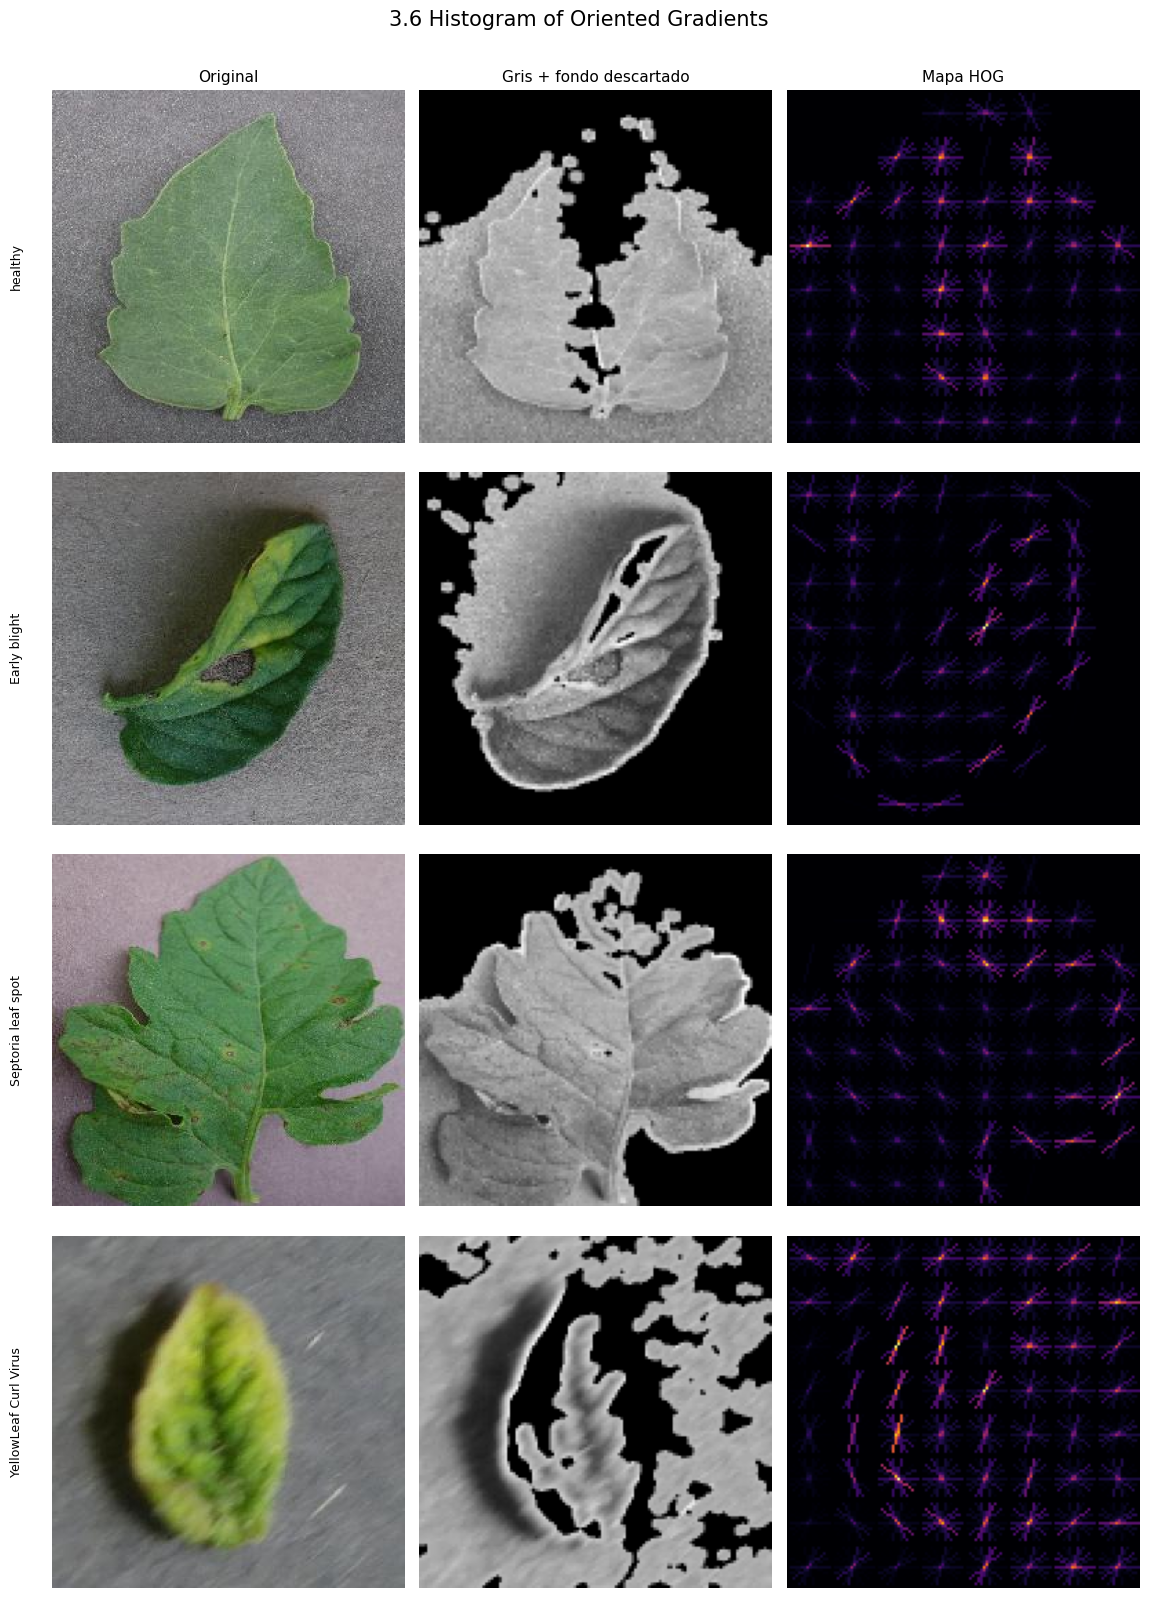

In [15]:
# --- Figura: mapas de HOG por clase ---
fig, axes = plt.subplots(len(muestra_procesada), 3,
                         figsize=(11.5, 4.0 * len(muestra_procesada)))
if len(muestra_procesada) == 1:
    axes = axes[np.newaxis, :]

for i, (ruta, clase, bgr, mascara) in enumerate(muestra_procesada):
    gray = preparar_para_descriptores(bgr, mascara)
    _, mapa = hog_vector_y_mapa(gray)

    axes[i, 0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title("Original" if i == 0 else "", fontsize=11)
    axes[i, 0].axis('off')
    axes[i, 0].text(-0.1, 0.5, etiqueta_corta(clase), transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title("Gris + fondo descartado" if i == 0 else "", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(mapa, cmap='inferno')
    axes[i, 2].set_title("Mapa HOG" if i == 0 else "", fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle("3.6 Histogram of Oriented Gradients", fontsize=15, y=1.002)
plt.tight_layout()
guardar("06_hog_mapas.png")
plt.show()

## 5. Vector combinado (LBP + HOG)

Cada imagen queda representada por la concatenación del histograma LBP (textura) y el vector
HOG (estructura/gradiente): dos descriptores complementarios en un solo vector.

In [11]:
def extraer_descriptores(bgr, mascara):
    """Vector de características combinado: histograma LBP + vector HOG."""
    gray = preparar_para_descriptores(bgr, mascara)
    lbp = lbp_histograma(lbp_mapa(gray))
    hog_vec, _ = hog_vector_y_mapa(gray)
    return np.concatenate([lbp, hog_vec])

# Prueba
ruta, clase, bgr, mascara = muestra_procesada[0]
vec = extraer_descriptores(bgr, mascara)
print("Vector combinado:", vec.shape, "=", LBP_N_BINS, "(LBP) +", vec.shape[0] - LBP_N_BINS, "(HOG)")

Vector combinado: (1774,) = 10 (LBP) + 1764 (HOG)


## 6. Matriz de datos para clasificación

Se arma la matriz `X` (una fila por imagen, una columna por característica) y el vector de
etiquetas `y`, usando `N_POR_CLASE_DATOS` imágenes de cada una de las 4 clases foco. Esta
matriz es la entrada de los clasificadores de la sección 3.7 (kNN, SVM, Random Forest).

In [12]:
N_POR_CLASE_DATOS = 40

filas, vectores = [], []
for clase in CLASES_FOCO:
    for ruta in imagenes_de_clase(clase, n=N_POR_CLASE_DATOS):
        bgr, mascara = procesar_hasta_operaciones_morfologicas(ruta)
        vectores.append(extraer_descriptores(bgr, mascara))
        filas.append({"ruta": ruta, "clase": clase, "sana": es_sana(clase)})

X = np.vstack(vectores)
y = np.array([f["clase"] for f in filas])

print("Matriz de características X:", X.shape)
print("  -> filas: imágenes  (", N_POR_CLASE_DATOS, "por clase x", len(CLASES_FOCO), "clases )")
print("  -> columnas: 0.." + str(LBP_N_BINS - 1), "= LBP  |", LBP_N_BINS, "..", X.shape[1] - 1, "= HOG")
print("Etiquetas y:", y.shape, "-> clases:", sorted(set(y)))

Matriz de características X: (160, 1774)
  -> filas: imágenes  ( 40 por clase x 4 clases )
  -> columnas: 0..9 = LBP  | 10 .. 1773 = HOG
Etiquetas y: (160,) -> clases: [np.str_('Tomato_Early_blight'), np.str_('Tomato_Septoria_leaf_spot'), np.str_('Tomato__Tomato_YellowLeaf__Curl_Virus'), np.str_('Tomato_healthy')]


In [ ]:
import pandas as pd

n_hog = X.shape[1] - LBP_N_BINS
columnas = [f"lbp_{i}" for i in range(LBP_N_BINS)] + [f"hog_{i}" for i in range(n_hog)]

df = pd.DataFrame(X, columns=columnas)
df.insert(0, "sana", [f["sana"] for f in filas])
df.insert(0, "clase", [f["clase"] for f in filas])
df.insert(0, "ruta", [f["ruta"] for f in filas])

ruta_csv = os.path.join(FEATS, "lbp_hog_features.csv")
df.to_csv(ruta_csv, index=False)
print("guardado:", ruta_csv, "|", df.shape)

ruta_npz = os.path.join(FEATS, "lbp_hog_features.npz")
np.savez(ruta_npz, X=X, y=y, n_lbp=LBP_N_BINS,
        rutas=np.array([f["ruta"] for f in filas]))
print("guardado:", ruta_npz)

df.head()

guardado: features/lbp_hog_features.csv | (160, 1777)
guardado: features/lbp_hog_features.npz


,ruta,clase,sana,lbp_0,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,...,hog_1754,hog_1755,hog_1756,hog_1757,hog_1758,hog_1759,hog_1760,hog_1761,hog_1762,hog_1763
0,/home/diegorandolp/.cache/kagglehub/datasets/e...,Tomato_healthy,True,0.085571,0.072754,0.032898,0.041565,0.044373,0.039307,0.034729,...,0.129367,0.216275,0.135359,0.171180,0.131219,0.161983,0.154819,0.153990,0.153696,0.114762
1,/home/diegorandolp/.cache/kagglehub/datasets/e...,Tomato_healthy,True,0.077820,0.066223,0.028687,0.034363,0.044922,0.037292,0.031555,...,0.160810,0.171674,0.117160,0.085536,0.159033,0.145058,0.128563,0.118054,0.100605,0.126446
2,/home/diegorandolp/.cache/kagglehub/datasets/e...,Tomato_healthy,True,0.075623,0.060059,0.028259,0.033936,0.040283,0.035156,0.029846,...,0.133475,0.149803,0.149748,0.127721,0.087975,0.156213,0.154422,0.100134,0.123676,0.097553
3,/home/diegorandolp/.cache/kagglehub/datasets/e...,Tomato_healthy,True,0.094482,0.076721,0.032776,0.043213,0.051208,0.049194,0.039612,...,0.145583,0.219006,0.159181,0.184970,0.170316,0.147864,0.148058,0.103991,0.092687,0.131204
4,/home/diegorandolp/.cache/kagglehub/datasets/e...,Tomato_healthy,True,0.093140,0.081665,0.037109,0.051636,0.064514,0.054993,0.035278,...,0.136345,0.140777,0.089597,0.098881,0.116727,0.183935,0.104686,0.163486,0.208242,0.153061
